# Relier le BOAMP aux DECP

Les deux sources décrivent les mêmes marchés et **ne partagent aucun identifiant**. Sur 600 avis
testés au notebook précédent, zéro correspondance.

Ce notebook répond à trois questions, dans l'ordre :

1. peut-on quand même les relier, et à quel taux ?
2. quels réglages retenir, et sur quelle preuve ?
3. les rapprochements obtenus sont-ils **justes** ?

La troisième question est la seule qui compte vraiment. Un taux de rapprochement élevé et faux vaut
moins que rien : il ferait afficher de fausses informations à l'utilisateur.

In [1]:
import sys
from datetime import date, timedelta
from difflib import SequenceMatcher

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")

from mesures.figures import GRIS, legender, soigner  # noqa: E402
from mesures.rapprochement_boamp_decp import charger_avis, interroger_boamp  # noqa: E402

%matplotlib inline

con = duckdb.connect()
con.register("decp", con.read_parquet("../donnees/brut/decp.parquet"))
con.execute("create or replace view marches as select * from decp where donneesActuelles")

# Avis de résultat du premier semestre 2025 : assez anciens pour que les DECP aient eu le temps
# de les contenir. Prendre des avis récents mesurerait surtout le délai de publication.
avis = charger_avis("2025-01-01", "2025-07-01", 300)
print(f"{len(avis)} avis de résultat chargés")

300 avis de résultat chargés


## 1. Trouver le SIRET, malgré trois formats

Première tentative, faite en écrivant ce notebook : lire le SIRET à l'emplacement prévu par le
format français FNSimple. Résultat : **19 %** des avis exploitables. De quoi abandonner.

L'erreur : les avis du BOAMP existent en trois formats. Vérifions.

In [2]:
# L'objet Avis ne garde que ce qui sert au rapprochement. Pour compter les formats, on redemande
# les documents bruts a l'API.
bruts = interroger_boamp(
    select="donnees",
    where="nature_libelle='Résultat de marché' and dateparution >= date'2025-01-01'"
    " and dateparution < date'2025-07-01'",
    order_by="dateparution",
    limit=100,
)["results"]


def format_de(document: object) -> str:
    """Reconnait le schema d'un avis a sa cle racine."""
    texte = str(document)
    for nom in ("EFORMS", "FNSimple", "MAPA"):
        if nom in texte:
            return nom
    return "autre"


pd.Series([format_de(b["donnees"]) for b in bruts]).value_counts()

EFORMS      87
FNSimple    10
MAPA         3
Name: count, dtype: int64

**Le format européen eForms domine largement.** Écrire un analyseur par format serait précis, mais
trois fois plus long à écrire et à maintenir, pour un gain incertain.

La règle retenue est plus simple : **chercher le motif de quatorze chiffres partout dans le
document**. Elle fonctionne sur les trois formats, et son imprécision est rattrapée en aval, car un
nombre qui n'est pas un SIRET ne correspondra à aucun acheteur des DECP.

C'est encore le principe de l'escalier : la règle la plus basse d'abord, et on ne monte que si la
mesure le réclame.

In [3]:
avec_siret = [a for a in avis if a.sirets]
print(
    f"{len(avec_siret)} avis sur {len(avis)} portent au moins un SIRET "
    f"({100 * len(avec_siret) / len(avis):.0f} %)"
)
print(
    f"nombre médian de SIRET par avis : "
    f"{int(pd.Series([len(a.sirets) for a in avec_siret]).median())}"
)

# Un avis contient le SIRET de l'acheteur, puis ceux des titulaires. L'ordre est stable.
exemple = avec_siret[0]
print(f"\nexemple : {exemple.idweb}")
print(f"  objet   : {exemple.objet[:90]}")
print(f"  SIRET   : {exemple.sirets}")

184 avis sur 300 portent au moins un SIRET (61 %)
nombre médian de SIRET par avis : 3

exemple : 24-145749
  objet   : travaux de réparation, d'entretien, de rénovation et de petites créations dans les bâtimen
  SIRET   : ['21130055300016', '35009850500026', '85095960200010', '43145520300023', '17130005600024']


Le taux passe de 19 % à **61 %**, rien qu'en cherchant au bon endroit.

**Leçon de méthode** : avant de conclure qu'une donnée manque, vérifier qu'on ne la cherche pas
au mauvais endroit. C'est la différence entre un projet abandonné et un projet qui avance.

## 2. Rapprocher, niveau par niveau

Quatre critères, ajoutés l'un après l'autre. Chacun est mesuré séparément, pour savoir ce qu'il
apporte réellement plutôt que de le supposer.

In [4]:
def candidats_pour(avis_un, mois=18):
    """Les marchés du même acheteur, dans une fenêtre de dates autour de la parution de l'avis."""
    acheteurs = con.execute(
        "select distinct acheteur_id from marches "
        "where acheteur_id in (select unnest(?::varchar[]))",
        [avis_un.sirets],
    ).fetchall()
    if not acheteurs:
        return None, []
    acheteur = acheteurs[0][0]
    parution = date.fromisoformat(avis_un.date)
    marches = con.execute(
        "select objet, titulaire_id from marches "
        "where acheteur_id = ? and dateNotification between ? and ?",
        [acheteur, parution - timedelta(days=mois * 30), parution + timedelta(days=90)],
    ).fetchall()
    return acheteur, marches


entonnoir = {
    "1. acheteur reconnu": 0,
    "2. candidats dans la fenêtre": 0,
    "3. objet proche": 0,
    "4. titulaire retrouvé": 0,
}
tailles = []

for un_avis in avec_siret:
    acheteur, marches = candidats_pour(un_avis)
    if acheteur is None:
        continue
    entonnoir["1. acheteur reconnu"] += 1
    if not marches:
        continue
    entonnoir["2. candidats dans la fenêtre"] += 1
    tailles.append(len(marches))

    autres = [s for s in un_avis.sirets if s != acheteur]
    scores = [SequenceMatcher(None, un_avis.objet, (o or "").lower()).ratio() for o, _ in marches]
    if max(scores) > 0.6:
        entonnoir["3. objet proche"] += 1
    if any(t and t in autres for _, t in marches):
        entonnoir["4. titulaire retrouvé"] += 1

pd.DataFrame(
    {
        "étape": list(entonnoir),
        "avis": list(entonnoir.values()),
        "part des 300": [f"{100 * v / len(avis):.1f} %" for v in entonnoir.values()],
    }
)

,étape,avis,part des 300
0,1. acheteur reconnu,159,53.0 %
1,2. candidats dans la fenêtre,141,47.0 %
2,3. objet proche,83,27.7 %
3,4. titulaire retrouvé,43,14.3 %


**Ce que l'entonnoir apprend**, et qui n'était pas prévisible :

In [5]:
print(
    f"candidats par avis après la fenêtre : "
    f"médiane {int(pd.Series(tailles).median())}, maximum {max(tailles)}"
)

candidats par avis après la fenêtre : médiane 105, maximum 1717


La fenêtre de dates **ne trie presque rien** : elle laisse en médiane une centaine de marchés
candidats. Ce sont l'objet et le titulaire qui discriminent réellement.

Cela oriente tout le reste : inutile d'affiner la fenêtre, c'est le seuil de similarité qu'il faut
régler.

## 3. Régler les deux paramètres, par la mesure

Deux réglages : la largeur de la fenêtre, et le seuil de similarité. Plutôt que de les choisir,
on balaie les valeurs et on regarde. Le calcul complet est dans `mesures/rapprochement_boamp_decp.py`,
lancé par `make bench-rapprochement` ; on relit ici son résultat.

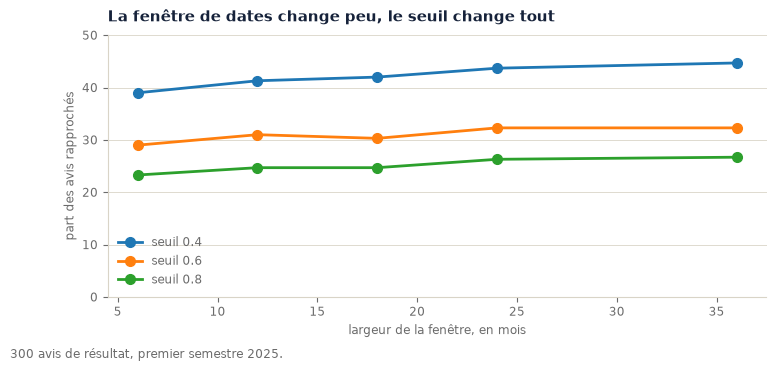

In [6]:
balayage = pd.read_csv("../mesures/resultats/2026-09-23-rapprochement-balayage.csv")

figure, axes = plt.subplots(figsize=(8.5, 3.4))
for seuil in (0.4, 0.6, 0.8):
    serie = balayage[balayage["seuil_objet"] == seuil]
    axes.plot(
        serie["fenetre_mois"],
        serie["part_rapproches"],
        marker="o",
        markersize=7,
        linewidth=2,
        label=f"seuil {seuil}",
    )
axes.set_xlabel("largeur de la fenêtre, en mois", color=GRIS, fontsize=8.5)
axes.set_ylabel("part des avis rapprochés", color=GRIS, fontsize=8.5)
axes.set_ylim(0, 50)
axes.legend(frameon=False, fontsize=8.5, labelcolor=GRIS)
soigner(axes, "La fenêtre de dates change peu, le seuil change tout")
legender(figure, "300 avis de résultat, premier semestre 2025.")
plt.show()

**Confirmation** : passer de 6 à 36 mois gagne quelques points. Passer de 0,8 à 0,4 en gagne vingt.

Mais un rapprochement de plus n'est un gain que s'il est juste. Question suivante.

## 4. Ces rapprochements sont-ils justes ?

Aucun calcul ne peut y répondre : il n'existe pas de vérité de référence. **Il faut lire les
paires.** Soixante ont été relues une par une, douze par tranche de similarité.

Le choix de la stratification n'est pas anodin : un tirage uniforme aurait donné surtout des cas
faciles, à forte similarité, et n'aurait rien appris sur la frontière. On veut au contraire autant
d'exemples là où la méthode doute que là où elle est sûre.

In [7]:
verdicts = pd.read_csv("../mesures/verification/2026-09-27-verdicts-rapprochement.csv")

# Deux exemples opposés, pour voir concrètement ce que la mesure manipule.
for tranche in ("0.4 a 0.5", "0.8 a 1.01"):
    ligne = verdicts[verdicts["tranche"] == tranche].iloc[0]
    print(f"--- similarité {ligne['similarite']}, verdict : {ligne['verdict_humain']} ---")
    print(f"  BOAMP : {ligne['objet_boamp'][:95]}")
    print(f"  DECP  : {ligne['objet_decp'][:95]}")

--- similarité 0.4, verdict : non ---
  BOAMP : appel d'offres ouvert
  DECP  : ACCORD CADRE MOE - CEREG
--- similarité 0.8, verdict : oui ---
  BOAMP : location longue duree sans option d'achat, maintenance et assistance de 4 vehicules frigorifiqu
  DECP  : LOCATION LONGUE DUREE SANS OPTION D’ACHAT, MAINTENANCE ET ASSISTANCE DE 4 VEHICULES FRIGORIFIQU


In [8]:
resume = (
    verdicts.groupby("tranche")["verdict_humain"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["oui", "non", "doute"], fill_value=0)
)
# Les doutes sont exclus du calcul : les compter comme justes gonflerait le résultat,
# les compter comme faux le sous-estimerait. Leur nombre reste affiché.
resume["justesse"] = (100 * resume["oui"] / (resume["oui"] + resume["non"])).round(1)
resume

verdict_humain,oui,non,doute,justesse
tranche,,,,
0.4 a 0.5,0,12,0,0.0
0.5 a 0.6,6,4,2,60.0
0.6 a 0.7,8,3,1,72.7
0.7 a 0.8,10,1,1,90.9
0.8 a 1.01,12,0,0,100.0


**La justesse croît régulièrement avec la similarité** : nulle sous 0,5, deux tiers vers 0,6,
totale au-dessus de 0,8.

Et un résultat qui valide la conception : **les 19 paires où le SIRET du titulaire concorde sont
toutes justes**. Le niveau 4 mérite bien son nom de confiance haute.

In [9]:
concordants = verdicts[verdicts["titulaire_concorde"] == "oui"]
print(
    f"{len(concordants)} paires où le SIRET du titulaire concorde, "
    f"{(concordants['verdict_humain'] == 'oui').sum()} justes"
)

19 paires où le SIRET du titulaire concorde, 19 justes


## 5. La table de décision

Reste à croiser les deux mesures : combien de rapprochements par seuil, et quelle part d'entre eux
est juste.

**Attention au piège de calcul.** L'échantillon relu est stratifié, douze paires par tranche, alors
que les tranches n'ont pas le même poids réel. Faire la moyenne des verdicts donnerait un chiffre
faux. Il faut pondérer chaque tranche par son effectif réel, ce que fait
`mesures/precision_rapprochement.py`.

In [10]:
table = pd.read_csv("../mesures/resultats/rapprochement-precision.csv")
table

,seuil_objet,rapproches_par_objet,couverture_pourcent,justesse_estimee_pourcent,rapprochements_justes_attendus
0,0.4,83,27.7,66.0,54.8
1,0.5,64,21.3,85.6,54.8
2,0.6,48,16.0,94.1,45.2
3,0.7,41,13.7,97.8,40.1
4,0.8,31,10.3,100.0,31.0


**Le résultat décisif** : les seuils 0,4 et 0,5 produisent le **même nombre de rapprochements
justes**, environ 55. Descendre de 0,5 à 0,4 n'ajoute donc aucune information utile, seulement
19 erreurs.

C'est le genre de constat qu'on ne peut pas deviner, et qui justifie à lui seul le temps passé à
relire soixante paires à la main.

## Ce que cette exploration décide

| Décision | Preuve |
|---|---|
| Extraire les SIRET par motif, sans analyseur par format | 19 % contre 61 % d'avis exploitables |
| Ne pas chercher à affiner la fenêtre de dates | de 6 à 36 mois, le gain est de quelques points |
| Ne jamais descendre le seuil sous 0,5 | 0,4 et 0,5 donnent autant de rapprochements justes |
| Afficher un degré de confiance, jamais un lien brut | la justesse va de 0 % à 100 % selon la tranche |
| Confiance haute quand le titulaire concorde | 19 paires sur 19 justes |

**Limite à énoncer** : les soixante verdicts ont été posés par une seule personne, sur lecture des
libellés. Deux libellés proches peuvent désigner deux lots d'un même marché, ce qui est un
rapprochement acceptable, ou deux marchés distincts, ce qui ne l'est pas. Un second relecteur
changerait probablement quelques verdicts, sans modifier la tendance.

Le détail de la décision est dans `docs/adr/0003-rapprochement-des-sources.md`.